# Single Systems

## Imports

In [1]:
# Numerical arrays.
import numpy as np

# Symbolic computation.
import sympy as sp

## Original

*This is a modified version of a notebook that originally appeared in the [Qiskit Textbook v2](https://github.com/Qiskit/platypus).*  
*The original notebook is covered by the [Apache License v2](https://github.com/Qiskit/platypus/blob/main/LICENSE).*  
*The latest version of the original notebook is available on [IBM's Quantum Learning site](https://learning.quantum.ibm.com/).*  

## Introduction

[Click here to see the Qiskit Video on this topic.](https://www.youtube.com/watch?v=3-c4xJa7Flk&list=PLOFEBzvs-VvqKKMXX4vbi4EB1uaErFMSO)

This notebook introduces the basic framework of quantum information:  

- quantum states as vectors with complex number entries,  
- measurements that allow classical information to be extracted from quantum states, and  
- operations on quantum states that are described by unitary matrices.  

We will restrict ourselves to the comparatively simple setting of a single system in isolation.  
In the next lesson, we will expand our view to multiple systems that can interact with one another and be correlated.  

There are two common mathematical descriptions of quantum information.  
The one introduced in this lesson is the simpler.  
It is sufficient for understanding many quantum algorithms.  

A more powerful description is the one in which quantum states are represented by *density matrices*.  
The density matrix description is essential to the study of quantum information, for several reasons.  
They can be used to model the effects of noise.  
Density matrices serve as a mathematical basis for quantum information theory and quantum cryptography.  

## Classical information  

We begin with an overview of classical information.  
Quantum and classical information are different in some pretty spectacular ways.  
However, their mathematical descriptions are quite similar.  

This section introduces the *Dirac notation*.  
Dirac notation is used to describe vectors and matrices in quantum information and computation.  

### Classical States and Probability Vectors

Suppose that we have a system that stores information.  
This system can be in one of a finite number of *classical states* at each instant.  
The term *classical state* should be understood in intuitive terms.  
We mean by it a configuration that can be recognized and described unambiguously.  

The best example is that of a *bit*, which is a system whose classical states are 0 and 1.  
Other examples include:  
- a standard six-sided die, whose classical states are 1, 2, 3, 4, 5, and 6;  
- a nucleobase in a strand of DNA, whose classical states are *A*, *C*, *G*, and *T*; and  
- a switch on an electric fan, whose classical states are (commonly) *high*, *medium*, *low*, and *off*.  

Specifying the classical states of a system are, in fact, the starting point.  
We *define* a bit to be a system that has classical states 0 and 1.  

Let $\mathsf{X}$ to the system being considered.  
We will use the symbol $\Sigma$ to refer to the set of classical states of $\mathsf{X}$.  

We will assume $\Sigma$ is finite and nonempty.  
There is not much point in a physical system that has no states at all.  
We should consider physical systems having infinitely many states, but we will ignore that for now.  
There are plenty of interesting ideas to explore even within only a finite number of states.  
From now on, we will take *classical state set* to mean any finite and nonempty set.  

#### Examples
- When $\mathsf{X}$ is a bit, $\Sigma = \{0,1\}$ (which is often called the *binary alphabet*).  
- When $\mathsf{X}$ is a six-sided die, $\Sigma = \{1,2,3,4,5,6\}$.  
- When $\mathsf{X}$ is an electric fan switch, $\Sigma = \{\mathrm{high}, \mathrm{medium}, \mathrm{low}, \mathrm{off}\}$.  

Sometimes, we might know for certain a system is in a given state.  
For example, we might know for sure that a given fan is set to $high$.
Sometimes, though, our knowledge of a system $\mathsf{X}$ is uncertain.  
We assign probabilities to the states of $\mathsf{X}$, resulting in a *probabilistic state*.  

Suppose $\mathsf{X}$ is a bit.  
We might know something about what happened to $\mathsf{X}$ in the past.  
Suppose we believe that $\mathsf{X}$ is in state $0$ with probability $3/4$ and in state $1$ with probability $1/4$.  
We can represent this as:  

$\operatorname{Pr}(\mathsf{X}=0) = \frac{3}{4} \quad \textrm{and} \quad \operatorname{Pr}(\mathsf{X}=1) = \frac{1}{4}$

A shorter way to represent this is as a column vector:  

$
\begin{bmatrix}
  \frac{3}{4} \\[1mm]
  \frac{1}{4}
\end{bmatrix}
$

The probability of the bit being $0$ is placed at the top of the vector.  
The probability of the bit being $1$ at the bottom.  
The order is simply because this is the conventional way to order the set $\{0,1\}$.  

In general, we can represent a probabilistic state as a vector of probabilities.  
The probabilities can be ordered in any way we choose.  
Sometimes there is some natural or default way to order a classical state.  
Any probabilistic state represented by a column vector must satisfy two properties:

1. All entries of the vector are *nonnegative real numbers*.  
2. The sum of the entries is equal to $1$.  

Any column vector that satisfies these two properties can be taken as a representation of a probabilistic state.  
We refer to vectors of this form as *probability vectors* for short.  
Operations on these probabilistic states can be represented by matrix multiplication.  
We discuss that below.  

### Exercise

Which one of these is a valid probability vector?

$a. \begin{bmatrix} \sqrt{2}\\ 1 - \sqrt{2} \end{bmatrix} \qquad b. \begin{bmatrix} 0.3 \\ 0.3 \end{bmatrix} \qquad c. \begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix}$

### Measuring Probabilistic States  

What happens when we *measure* a system in a probabilistic state?
We look at the system and unambiguously recognize whatever classical state it is in.
We can never *see* a system in a probabilistic state.
Measurement yields exactly one of the classical states.

Measurement changes our knowledge of the system.
It changes the probabilistic state that we associate with that system.
Suppose we measure $\mathsf{X}$ in the classical state $a\in\Sigma$.
Our new probability vector representing our knowledge of $\mathsf{X}$ becomes a vector having a $1$ in the entry corresponding to $a$ and $0$ for all other entries.
This vector indicates that $\mathsf{X}$ is in the classical state $a$ with certainty, which we know having just recognized it.

We denote the vector having a $1$ in the entry corresponding to $a$ and $0$ for all other entries by $\ket{a}$.
We pronounce $\ket{a}$ as *ket a*.
Vectors of this sort are called *standard basis* vectors.

For a single bit, the standard basis vectors are:  

$\ket{0} = \begin{bmatrix} 1 \\ 0 \end{bmatrix} \quad \textrm{and}  \quad \ket{1} = \begin{bmatrix}0\\1\end{bmatrix}$.  

Any two-dimensional column vector can be expressed as a linear combination of these two vectors:

$\begin{bmatrix}
  \frac{3}{4}\\[1mm]
  \frac{1}{4}
\end{bmatrix}
= \frac{3}{4}\,\ket{0} + \frac{1}{4}\,\ket{1}$.  

Any column vector is a linear combination over the classical states.
What happens when we measure a probabilistic state?
Suppose we flip a fair coin, but cover up the coin before looking at it.
The classical state set of our coin is $\{\text{heads},\text{tails}\}$.
We will order these states as heads first, tails second:

$\ket{\text{heads}} = \begin{bmatrix}1\\0\end{bmatrix} \quad \textrm{and}  \quad \ket{\text{tails}} = \begin{bmatrix}0\\1\end{bmatrix}$.

Then the probabilistic state is:

$\begin{bmatrix}
  \frac{1}{2}\\[1mm]
  \frac{1}{2}
\end{bmatrix}
= \frac{1}{2}\,\ket{\text{heads}} + \frac{1}{2}\,\ket{\text{tails}}$.  

If we uncover the coin and look at it, we would see one of the two classical states: $\text{heads}$ or $\text{tails}$.
Suppose the result is tails.
We must update our probabilistic state to $\ket{\text{tails}}$.
If we cover the coin again and uncover it again, the state would still be $\text{tails}$.
This may seem obvious but quantum systems behave similarly and yet their measurement properties are frequently considered unusual.

One final remark concerning probabilistic states.
They may describe knowledge or belief, not necessarily something actual.
The state of our coin after it is flipped it is either heads or tails.
Before we look, we just do not know which.
Looking does not change the state, only our knowledge of it.

Upon seeing the state is tails, we update our probability vector to $\ket{\text{tails}}$.
However, someone who did not see the coin would not update their vector.
Different individuals may have different knowledge or beliefs about a system.

### Classical operations  

Now let's consider the sorts of operations one might perform on a classical system.

#### Deterministic operations  

First, there are deterministic operations, where each classical state $a \in \Sigma$ is transformed into $f(a)$ for some function $f$ of the form $f:\Sigma \rightarrow \Sigma$.
For example, if $\Sigma = \{0,1\}$, there are four functions, $f_1$, $f_2$, $f_3$, and $f_4$:

$
\begin{array}{c|c}
  a & f_1(a)\\
  \hline
  0 & 0\\
  1 & 0
\end{array}
\quad
\begin{array}{c|c}
  a & f_2(a)\\
  \hline
  0 & 0\\
  1 & 1
\end{array}
\quad
\begin{array}{c|c}
  a & f_3(a)\\
  \hline
  0 & 1\\
  1 & 0
\end{array}
\quad
\begin{array}{c|c}
  a & f_4(a)\\
  \hline
  0 & 1\\
  1 & 1
\end{array}
$

The first and last of these functions are *constant*: $f_1(a) = 0$ and $f_4(a) = 1$ for each $a\in\Sigma$.
The middle two are not constant, they are *balanced*.
The two possible output values occur the same number of times as we range over the possible inputs.
The function $f_2$ is the identity function: $f_2(a) = a$ for each $a \in \Sigma$.
And $f_3$ is the function $f_3(0) = 1$ and $f_3(1) = 0$ which is better-known as the NOT function.

The actions of deterministic operations on probabilistic states can be represented by matrix-vector multiplication.
Specifically, the matrix $M$ that represents a given function $f:\Sigma \rightarrow \Sigma$ is the one that satisfies

$M \ket{a} = \ket{f(a)}$

for every $a \in \Sigma$.
Such a matrix always exists and is unique.
For example, the matrices $M_1,M_2,M_3$ and $M_4$ corresponding to the functions $f_1,f_2,f_3$ and $f_4$ are:

$
  M_1 = \begin{bmatrix} 1 & 1 \\ 0 & 0 \end{bmatrix},
  \quad
  M_2 = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix},
  \quad
  M_3 = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix},
  \quad
  M_4 = \begin{bmatrix} 0 & 0 \\ 1 & 1 \end{bmatrix}
$.

Matrices that represent deterministic operations always have exactly one $1$ in each column, and $0$ for all other entries.

A convenient way to represent matrices of these and other forms makes use of an analogous notation for row vectors to the one for column vectors discussed previously. We denote by $\bra{a}$ the *row* vector having a $1$ in the entry corresponding to $a$ and zero for all other entries, for each $a \in \Sigma$.
This vector is read as *bra a*.

For example, if $\Sigma = \{0,1\}$, then

$\bra{0} = \begin{bmatrix} 1 & 0 \end{bmatrix}
 \quad\text{and}\quad
 \bra{1} = \begin{bmatrix} 0 & 1 \end{bmatrix}
$.

For an arbitrary choice of a classical state set $\Sigma$, viewing row vectors and column vectors as matrices and performing the matrix multiplication $\ket{b} \bra{a}$, one obtains a square matrix having a $1$ in the entry corresponding to the pair $(b,a)$, meaning that the row of the entry corresponds to $b$ and the column corresponds to $a$, and $0$ for all other entries. For example,

$\ket{0} \bra{1} = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix}
$.

Using this notation, for any function $f:\Sigma \rightarrow \Sigma$, we may express the matrix $M$ corresponding to the function $f$ as 

$M = \sum_{a \in \Sigma} \ket{f(a)} \bra{a}$.  

Now, if we again think about vectors as matrices, but this time consider the multiplication $\bra{a} \ket{b}$, then we obtain a $1\times 1$ matrix, which we can think about as a scalar (i.e., a number).
For the sake of tidiness we write this product as $\braket{a \vert b}$.
This product satisfies the following simple formula:

$
  \braket{a \vert b}
  = \begin{cases}
    1 & a = b\\
    0 & a \not= b.
  \end{cases}
$

Using this observation, together with the fact that matrix multiplication is associative and linear, we obtain

$
  M \ket{b} = 
  \left(
  \sum_{a \in \Sigma} \ket{f(a)} \bra{a}
  \right)
  \ket{b}
  = \sum_{a \in \Sigma} \ket{f(a)} \braket{a \vert b}
  = \ket{f(b)}
$

for each $b \in \Sigma$, which is what we require of $M$.

As we will discuss in greater detail in Lesson 3, $\braket{a \vert b}$ may also be seen as an *inner product* between the vectors $\ket{a}$ and $\ket{b}$.
Inner products are critically important in quantum information, but we will delay a discussion of them until they are needed.

At this point the names *bra* and *ket* may be evident.
Putting a *bra* $\bra{a}$ together with a *ket* $\ket{b}$ yields a *bracket* $\braket{a \vert b}$.
This notation and terminology is due to Paul Dirac, and for this reason is known as *Dirac notation*.

#### Probabilistic operations and stochastic matrices

In addition to deterministic operations, we have *probabilistic operations*.

For example, consider an operation on a bit where, if the classical state of the bit is $0,$ it is left alone, and if the classical state of the bit is $1,$ it is flipped to $0$ with probability $1/2.$
This operation is represented by the matrix

$\begin{bmatrix} 1 & \frac{1}{2}\\[1mm] 0 & \frac{1}{2} \end{bmatrix}$

We can check that this matrix does the correct thing by multiplying with the standard basis vectors. 

For an arbitrary choice of a classical state set, we can describe the set of all probabilistic operations in mathematical terms as those that are represented by stochastic matrices, which are matrices satisfying these two properties:

1. All entries are nonnegative real numbers.
2. The entries in every column sum to 1.

Equivalently, stochastic matrices are matrices whose columns all form probability vectors.

We can think about probabilistic operations at an intuitive level as ones where randomness might somehow be used or introduced during the operation, just like in the example above.
With respect to the stochastic matrix description of a probabilistic operation, each column can be viewed as a vector representation of the probabilistic state that is generated given whatever classical state input corresponds to that column.

We can also think about stochastic matrices as being exactly those matrices that always map probability vectors to probability vectors.
That is, stochastic matrices always map probability vectors to probability vectors, and any matrix that always maps probability vectors to probability vectors must be a stochastic matrix.

Finally, another way to think about probabilistic operations is that they are random choices of deterministic operations.
For instance, we can think about the operation in the example above as applying either the identity function or the constant 0 function, each with probability $1/2$.
This is consistent with the equation

$\begin{bmatrix} 1 & \frac{1}{2} \\[1mm] 0 & \frac{1}{2} \end{bmatrix} =
  \frac{1}{2} \begin{bmatrix} 1 & 0 \\[1mm] 0 & 1 \end{bmatrix} +
  \frac{1}{2} \begin{bmatrix} 1 & 1 \\[1mm] 0 & 0 \end{bmatrix}$.

Such an expression is always possible, for an arbitrary choice of a classical state set and any stochastic matrix with rows and columns identified with that classical state set.

#### Compositions of probabilistic operations

Suppose that $\mathsf{X}$ is a system having classical state set $\Sigma$, and $M_1,\ldots,M_n$ are stochastic matrices representing probabilistic operations on the system $\mathsf{X}$.

If the first operation $M_1$ is applied to the probabilistic state represented by a probability vector $u$, the resulting probabilistic state is represented by the vector $M_1 u.$
If we then apply the second probabilistic operation $M_2$ to this new probability vector, we obtain the probability vector

$
  M_2 (M_1 u) = (M_2 M_1) u.
$

The equality follows from the fact that matrix multiplication (which includes matrix-vector multiplication as a special case) is an [associative](gloss:associative) operation.
Thus, the probabilistic operation obtained by [composing](gloss:composing) the first and second probabilistic operations, where we first apply $M_1$ and then apply $M_2$, is represented by the matrix $M_2 M_1$, which is necessarily stochastic.

More generally, composing the probabilistic operations represented by the matrices $M_1,\ldots,M_n$ in that order, meaning that $M_1$ is applied first, $M_2$ is applied second, and so on, with $M_n$ applied last, is represented by
the matrix

$
  M_n \,\cdots\, M_1.
$

Note that the ordering is important here: although matrix multiplication is associative, it is not a commutative operation in general.

For example, if we have

$
  M_1 = 
  \begin{bmatrix}
    1 & 1\\[1mm]
    0 & 0
  \end{bmatrix}
  \quad\text{and}\quad
  M_2 =
  \begin{bmatrix}
    0 & 1\\[1mm]
    1 & 0
  \end{bmatrix},
$

then

$
  M_2 M_1 = 
  \begin{bmatrix}
    0 & 0 \\[1mm]
    1 & 1
  \end{bmatrix}
  \quad\text{and}\quad
  M_1 M_2 =
  \begin{bmatrix}
    1 & 1\\[1mm]
    0 & 0
  \end{bmatrix}
$.

That is, the order in which probabilistic operations are composed matters: changing the order in which operations are applied in a composition can change the resulting operation.

## Quantum information

Now we move on to quantum information, where we make a different choice for the type of vector that represents a state — in this case a *quantum state* — of the system being considered.
As in the previous section, we'll be concerned with systems having finite and nonempty sets of classical states, and we will make use of much of the notation that was introduced in that section.

### Quantum state vectors

A *quantum state* of a system is represented by a column vector, similar to probabilistic states. As before, the indices of the vector label the classical states of the system.
Vectors representing quantum states are characterized by these two properties:

1. The entries of a quantum state vector are *complex numbers*.
2. The sum of the *absolute values squared* of the entries of a quantum state vector must equal $1.$

Thus, in contrast to the probabilistic case, vectors representing quantum states need not have nonnegative real number entries, and it is the sum of the absolute values squared of the entries (as opposed to the sum of the entries) that must equal $1.$ Simple as these changes are, they give rise to all the differences between quantum and classical information. Any speedup from a quantum computer, or improvement in a communication protocol, ultimately derives from these simple mathematical changes. 

The *Euclidean norm* of a column vector

$v = \begin{bmatrix} \alpha_1 \\ \vdots \\ \alpha_n \end{bmatrix}$

is denoted and defined as follows:

$\| v \| = \sqrt{\sum_{k=1}^n |\alpha_k|^2}$.

The condition that the sum of the absolute values squared of a quantum state vector equals $1$ is therefore equivalent to that vector having Euclidean norm equal to $1.$
That is, quantum state vectors are *unit vectors* with respect to the Euclidean norm.

#### Examples of Qubit States

The term *qubit* refers to a quantum system whose classical state set is $\{0,1\}$.
That is, a qubit is really just a bit — but by using this name we explicitly recognize that this bit can be in a quantum state.

These are examples of quantum states of a qubit:

$
  \begin{bmatrix}
    1\\[2mm]
    0
  \end{bmatrix}
  = \ket{0}
  \quad\text{and}\quad
  \begin{bmatrix}
    0\\[2mm]
    1
  \end{bmatrix}
  = \ket{1},
$

$
  \begin{bmatrix}
    \frac{1}{\sqrt{2}}\\[2mm]
    \frac{1}{\sqrt{2}}
  \end{bmatrix}
  = \frac{1}{\sqrt{2}}\,\ket{0} + \frac{1}{\sqrt{2}}\,\ket{1},
$
and
$
  \begin{bmatrix}
    \frac{1+2i}{3}\\[2mm]
    -\frac{2}{3}
  \end{bmatrix}
  = \frac{1+2i}{3}\,\ket{0} - \frac{2}{3}\,\ket{1}.
$

The first two examples, $\ket{0}$ and $\ket{1}$, illustrate that standard basis elements are valid quantum state vectors: their entries are complex numbers (where the imaginary part of these numbers happens to be $0$) and computing the sum of the absolute values squared of the entries yields

$
  \vert 1\vert^2 + \vert 0\vert^2 = 1
  \quad\text{and}\quad
  \vert 0\vert^2 + \vert 1\vert^2 = 1,
$

as required.
Similar to the classical setting, we associate the quantum state vectors $\vert 0\rangle$ and $\vert 1\rangle$ with a qubit being in the classical state $0$ or $1$, respectively, with certainty.

For the other two examples, we again have complex number entries, and computing the sum of the absolute value squared of the entries yields

$
  \left\vert\frac{1}{\sqrt{2}}\right\vert^2 +
  \left\vert\frac{1}{\sqrt{2}}\right\vert^2 = \frac{1}{2} + \frac{1}{2} = 1
$

and

$
  \left\vert \frac{1+2i}{3} \right\vert^2 +
  \left\vert -\frac{2}{3} \right\vert^2 = \frac{5}{9} + \frac{4}{9} = 1.
$

These are therefore valid quantum state vectors. Note that they are linear combinations of the states $\ket{0}$ and $\ket{1}$. We often say that these states are *superpositions* of the $0$ and $1$ states. Within the context of quantum states, "superposition" and "linear combination" are essentially synonymous. 

The example $(1)$ of a qubit state vector above is very commonly encountered — it is called the *plus state* and is denoted as follows:

$
  \ket{+} = \frac{1}{\sqrt{2}} \ket{0} + \frac{1}{\sqrt{2}} \ket{1}.
$

We also use the notation

$
  \ket{-} = \frac{1}{\sqrt{2}} \ket{0} - \frac{1}{\sqrt{2}} \ket{1}
$

to refer to a related quantum state vector where the second entry is negative rather than positive, and we call this state the *minus state*.
This sort of notation, where some symbol other than one referring to a classical state appears inside of a ket, is common — we can use whatever name we wish inside of a ket to name a vector.

Indeed, it is quite common to use a notation such as $\ket{\psi}$, or other names in place of $\psi$, to refer to arbitrary vectors that may not necessarily be a standard basis vector: $\psi$ is simply a name for the vector, but it is put inside a ket, which stresses that it is a vector.

Notice that if we have a vector $\ket{\psi}$ whose indices correspond to some classical state set $\Sigma$, and if $a\in\Sigma$ is an element of this classical state set, then the (matrix) product $\braket{a \vert \psi}$ is equal to the entry of the vector $\ket{\psi}$ whose index corresponds to $a$.

For example, if $\Sigma = \{0,1\}$ and

$
\ket{\psi} =
\frac{1+2i}{3} \ket{0} - \frac{2}{3} \ket{1}
= \begin{bmatrix}
    \frac{1+2i}{3}\\[2mm]
    -\frac{2}{3}
  \end{bmatrix},
$

then

$
  \braket{0 \vert \psi} \rangle = \frac{1+2i}{3}
  \quad\text{and}\quad
  \braket{1 \vert \psi} = -\frac{2}{3}.
$

It must be understood when using this notation that $\bra{\psi}$ refers to the row vector obtained by taking the *conjugate-transpose* of the column vector $\ket{\psi}$, where (in addition to transposing the vector from a column vector to a row vector) each entry is replaced by its complex conjugate.

For example, if $\ket{\psi}$ is the vector defined in $(2)$, then

$
\bra{\psi} = \frac{1-2i}{3} \bra{0} - \frac{2}{3} \bra{1}
= \begin{bmatrix}
    \frac{1-2i}{3} &
    -\frac{2}{3}
  \end{bmatrix}.
$

The reason we take the complex conjugate, in addition to the transpose, will become more clear in Lesson 3 when we discuss the *inner product*.

#### Quantum states of other systems

We can consider quantum states of systems having arbitrary classical state sets.

For example, here is a quantum state vector for an electrical fan switch:

$$
  \begin{pmatrix}
    \frac{1}{2}\\[1mm]
    0 \\[1mm]
    -\frac{i}{2}\\[1mm]
    \frac{1}{\sqrt{2}}
  \end{pmatrix}
  =    
  \frac{1}{2} \vert\mathrm{high}\rangle
  - \frac{i}{2} \vert\mathrm{low}\rangle
  + \frac{1}{\sqrt{2}} \vert\mathrm{off}\rangle.
$$

The assumption here is that the classical states are ordered as *high*, *medium*, *low*, *off*.
There may be no particular reason why one would want to consider a quantum state of an electrical fan switch, but it is possible in principle.

Here is another example, this time of a quantum decimal digit whose classical states are $0, 1, \ldots, 9$:

$$
  \frac{1}{\sqrt{385}}
  \begin{pmatrix}
    1\\
    2\\
    3\\
    4\\
    5\\
    6\\
    7\\
    8\\
    9\\
    10
  \end{pmatrix}
  =
  \frac{1}{\sqrt{385}}\sum_{k = 0}^9 (k+1) \vert k \rangle.
$$

This example illustrates the convenience of writing state vectors using the Dirac notation.
For this particular example, the column vector representation is merely cumbersome — but if there were significantly more classical states it would become unusable.
The Dirac notation, in contrast, supports precise descriptions of large and complicated vectors in a compact form.

The Dirac notation also allows for the expression of vectors where different aspects of the vectors are *indeterminate* (meaning unknown or not yet established).
For example, for an arbitrary classical state set $\Sigma$, we can consider the quantum state vector

$$
  \frac{1}{\sqrt{|\Sigma|}} \sum_{a\in\Sigma} \vert a \rangle,
$$

which is a uniform superposition over the classical states in $\Sigma$.
(Here, the notation $\vert\Sigma\vert$ refers to the number of elements in $\Sigma$.)

We'll encounter much more complicated expressions of quantum state vectors in later lessons, where the use of column vectors would be impractical or impossible.
In fact, we'll mostly abandon the column vector representation of state vectors, except for vectors having a small number of entries (often in the context of examples), where it may be helpful to display and examine the entries explicitly.

There is one more reason why expressing state vectors using the Dirac notation is generally more convenient: it alleviates the need to explicitly specify an ordering of the classical states (or, equivalently, the correspondence between classical states and vector indices).
For example, a quantum state vector for a system having classical state set 
$\{\clubsuit,\diamondsuit,\heartsuit,\spadesuit\}$, such as

$$
    \frac{1}{2} \vert\clubsuit\rangle
  + \frac{i}{2} \vert\diamondsuit\rangle
  - \frac{1}{2} \vert\heartsuit\rangle
  - \frac{i}{2} \vert\spadesuit\rangle,
$$

is unambiguously described by this expression, and there really is no need to choose or specify an ordering of this classical state set in order to make sense of the expression.
In this case, it is not difficult to simply specify an ordering of the standard card suits — for instance, we could order them as follows: $\clubsuit$, $\diamondsuit$, $\heartsuit$, $\spadesuit$.
If we choose this particular ordering, the quantum state vector above is represented by the column vector

$$
\begin{pmatrix}
 \frac{1}{2}\\[2mm]
 \frac{i}{2}\\[2mm]
 -\frac{1}{2}\\[2mm]
 -\frac{i}{2}
\end{pmatrix}.
$$

In general, however, it is convenient to simply ignore the question of how classical state sets are ordered, and take the view that quantum state vectors are directly indexed by classical states.

### Measuring quantum states 

Next let us consider what happens when a quantum state is *measured*, focusing on a simple type of measurement known as a *standard basis measurement*.
(There are more general notions of measurement that will be discussed later on.)

Similar to the probabilistic setting, when a system in a quantum state is measured, the observer performing the measurement won't see a quantum state vector, but rather some classical state.
In this sense, measurements act as the interface between quantum and classical information, through which classical information is extracted from quantum states.

The rule is simple: if a quantum state is measured, each classical state of the system results with probability equal to the *absolute value squared* of the entry in the quantum state vector corresponding to that classical state.
This is known as the *Born rule* in quantum mechanics.
Notice that this rule is consistent with the requirement that the absolute values squared of the entries in a quantum state vector sum to 1, as it implies that the probabilities of different classical state measurement outcomes sum to $1.$

For example, measuring the plus state

$$
  \vert + \rangle = 
  \frac{1}{\sqrt{2}} \vert 0 \rangle
  + \frac{1}{\sqrt{2}} \vert 1 \rangle
$$

results in the two possible outcomes, $0$ and $1,$ with probabilities as follows.

$$
  \operatorname{Pr}(\text{outcome is 0})
  = \bigl\vert \langle 0 \vert + \rangle \bigr\vert^2
  = \biggl\vert \frac{1}{\sqrt{2}} \biggr\vert^2
  = \frac{1}{2}
$$

$$
  \operatorname{Pr}(\text{outcome is 1})
  = \bigl\vert \langle 1 \vert + \rangle \bigr\vert^2
  = \biggl\vert \frac{1}{\sqrt{2}} \biggr\vert^2
  = \frac{1}{2}
$$

Interestingly, measuring the minus state

$$
  \vert - \rangle = 
  \frac{1}{\sqrt{2}} \vert 0 \rangle
  - \frac{1}{\sqrt{2}} \vert 1 \rangle
$$

results in exactly the same probabilities for the two outcomes.

$$
  \operatorname{Pr}(\text{outcome is 0})
  = \bigl\vert \langle 0 \vert - \rangle \bigr\vert^2
  = \biggl\vert \frac{1}{\sqrt{2}} \biggr\vert^2
  = \frac{1}{2}
$$

$$
  \operatorname{Pr}(\text{outcome is 1})
  = \bigl\vert \langle 1 \vert - \rangle \bigr\vert^2
  = \biggl\vert -\frac{1}{\sqrt{2}} \biggr\vert^2
  = \frac{1}{2}
$$

This suggests that, as far as standard basis measurements are concerned, the plus and minus states are exactly the same. Why should we care to make a distinction, then? We will begin to address this question in the Section 2.3 below.

As a final example, measuring the state

$$
  \vert \psi \rangle = \frac{1+2i}{3} \vert 0\rangle - \frac{2}{3} \vert 1\rangle
$$

has probabilities given by

$$
  \operatorname{Pr}(\text{outcome is 0})
  = \bigl\vert \langle 0 \vert \psi \rangle \bigr\vert^2
  = \biggl\vert \frac{1+2i}{3} \biggr\vert^2
  = \frac{5}{9},
$$

and

$$
  \operatorname{Pr}(\text{outcome is 1})
  = \bigl\vert \langle 1 \vert \psi \rangle \bigr\vert^2
  = \biggl\vert -\frac{2}{3} \biggr\vert^2
  = \frac{4}{9}.
$$

Of course, measuring the quantum state $\vert 0\rangle$ results in the classical state $0$ with certainty, and likewise measuring the quantum state $\vert 1\rangle$ results in the classical state $1$ with certainty. 
This is consistent with the identification of these quantum states with the system *being* in the corresponding classical state, as was suggested previously.

### Unitary operations

Thus far, it may not be evident why quantum information is fundamentally different from classical information.
That is, when a quantum state is measured, the probability to obtain each classical state is given by the absolute value squared of the corresponding vector entry — so why not simply record these probabilities in a probability
vector?

The answer, at least in part, is that the set of allowable *operations* that can be performed on a quantum state is different than it is for classical information.
Similar to the probabilistic setting, operations on quantum states are linear mappings — but rather than being represented by stochastic matrices as in the classical case, operations on quantum state vectors are represented by *unitary* matrices.

A square matrix $U$ having complex number entries is unitary if it satisfies the equations

$$
  \begin{aligned}
    U U^{\dagger} &= \mathbb{1} \\
    U^{\dagger} U &= \mathbb{1}.
  \end{aligned}
$$

Here, $\mathbb{1}$ is the identity matrix, and $U^{\dagger}$ is the *conjugate transpose* of $U$, meaning the matrix obtained by transposing $U$ and taking the complex conjugate of each entry.
$$
  U^{\dagger} = \overline{U^T}
$$
If either of the equalities in the equation above is true, then the other must also be true; both equalities are equivalent to $U^{\dagger}$ being the inverse of $U$:

$$
  U^{-1} = U^{\dagger}.
$$

(Warning: if $M$ is not a square matrix, then it could be that $M^{\dagger} M = \mathbb{1}$ and $M M^{\dagger} \not= \mathbb{1}$, for instance.
The equivalence of the two equalities in the first equation above is only true for square matrices.)

The condition that $U$ is unitary is equivalent to the condition that multiplication by $U$ does not change the Euclidean norm of any vector.
That is, an $n\times n$ matrix $U$ is unitary if and only if 
$\\| U \vert \psi \rangle \\| = \\|\vert \psi \rangle \\|$
for every $n$-dimensional column vector $\vert \psi \rangle$ with complex number entries.
Thus, because the set of all quantum state vectors is the same as the set of vectors having Euclidean norm equal to $1,$ multiplying a unitary matrix to a quantum state vector results in another quantum state vector.

Indeed, unitary matrices are exactly the set of linear mappings which transform quantum state vectors to other quantum state vectors. Notice here a resemblance to the classical probabilistic case, where operations are associated with stochastic matrices, which are the ones that always transform probability vectors into probability vectors.


### Quick quiz

Which one of these matrices is unitary?

1. $\begin{pmatrix} 1 & 0 \\\\ 1 & 0 \end{pmatrix}$


2. $\begin{pmatrix} 0 & \frac{1}{2} \\\\ \frac{-i}{2} & 0 \end{pmatrix}$


3. $\begin{pmatrix} 1 & 0 \\\\ 0 & i \end{pmatrix}$


#### Important examples of unitary operations on qubits

The following list describes some important unitary operations on qubits.


1. *Pauli operations.* The four Pauli matrices are as follows:        

   $$
     \mathbb{1} =
     \begin{pmatrix}
       1 & 0\\
       0 & 1
     \end{pmatrix},
     \quad
     \sigma_x =
     \begin{pmatrix}
       0 & 1\\
       1 & 0
     \end{pmatrix},
     \quad
     \sigma_y =
     \begin{pmatrix}
       0 & -i\\
       i & 0
     \end{pmatrix},
     \quad
     \sigma_z =
     \begin{pmatrix}
       1 & 0\\
       0 & -1
     \end{pmatrix}.
   $$
   
   A common notation, which we will often use, is $X = \sigma_x$, $Y = \sigma_y$, and $Z = \sigma_z$ — but be aware that the letters $X$, $Y$, and $Z$ are also commonly used for other purposes. The $\sigma_x$ (or $X$) operation is also called a *bit flip* or a *NOT operation* because it induces this action on bits:

   $$
     \sigma_x \vert 0\rangle = \vert 1\rangle 
     \quad \text{and} \quad
     \sigma_x \vert 1\rangle = \vert 0\rangle.
   $$

   The $\sigma_z$ (or $Z$) operation is also called a *phase flip* because it has this action:
    
   $$
     \sigma_z \vert 0\rangle = \vert 0\rangle
     \quad \text{and} \quad
     \sigma_z \vert 1\rangle = - \vert 1\rangle.
   $$

2. *Hadamard operation*. The Hadamard operation is described by this matrix:

   $$
     H = \begin{pmatrix}
       \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\[2mm]
       \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}
     \end{pmatrix}.
   $$

3. *Phase operations.*  A phase operation is one described by the matrix 

   $$
     P_{\theta} =
     \begin{pmatrix}
       1 & 0\\
       0 & e^{i\theta}
     \end{pmatrix}
   $$

   for any choice of a real number $\theta$.
   The operations
   
   $$
     S = P_{\pi/2} =
     \begin{pmatrix}
       1 & 0\\
       0 & i
     \end{pmatrix}
     \quad \text{and} \quad
     T = P_{\pi/4} =
     \begin{pmatrix}
       1 & 0\\
       0 & \frac{1 + i}{\sqrt{2}}
     \end{pmatrix}
   $$

   are particularly important examples. Other examples include $\mathbb{1} = P_0$ and $\sigma_z = P_{\pi}$.

  
All of the matrices just defined are unitary, and therefore represent quantum operations on a single qubit.

For example, here is a calculation that verifies that $H$ is unitary:

$$
  \begin{aligned}
  \begin{pmatrix}
    \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\[2mm]
    \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}
  \end{pmatrix}^{\dagger}
  \begin{pmatrix}
    \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\[2mm]
    \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}
  \end{pmatrix}
  & =
  \begin{pmatrix}
    \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\[2mm]
    \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}
  \end{pmatrix}
  \begin{pmatrix}
    \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\[2mm]
    \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}
  \end{pmatrix}\\[2mm]
  & = \begin{pmatrix}
    \frac{1}{2} + \frac{1}{2} & \frac{1}{2} - \frac{1}{2}\\[2mm]
    \frac{1}{2} - \frac{1}{2} & \frac{1}{2} + \frac{1}{2}
  \end{pmatrix}\\[2mm]
  & =
  \begin{pmatrix}
    1 & 0\\
    0 & 1
  \end{pmatrix}.
  \end{aligned}
$$

Here is the action of the Hadamard operation on a few qubit state vectors.

$$
   \begin{aligned}
  H \vert 0 \rangle & = 
  \begin{pmatrix}
    \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\[2mm]
    \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}
  \end{pmatrix}
  \begin{pmatrix}
    1\\[2mm]
    0
  \end{pmatrix}
  =
  \begin{pmatrix}
    \frac{1}{\sqrt{2}}\\[2mm]
    \frac{1}{\sqrt{2}}
  \end{pmatrix}
  = \vert + \rangle,\\[2mm]
  H \vert 1 \rangle
  & =
  \begin{pmatrix}
    \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\[2mm]
    \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}
  \end{pmatrix}
  \begin{pmatrix}
    0\\[2mm]
    1
  \end{pmatrix}
  =
  \begin{pmatrix}
    \frac{1}{\sqrt{2}}\\[2mm]
    -\frac{1}{\sqrt{2}}
  \end{pmatrix}
  = \vert - \rangle,\\[2mm]
  H \vert + \rangle
  & =
  \begin{pmatrix}
    \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\[2mm]
    \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}
  \end{pmatrix}
  \begin{pmatrix}
    \frac{1}{\sqrt{2}}\\[2mm]
    \frac{1}{\sqrt{2}}
  \end{pmatrix}
  =
  \begin{pmatrix}
    1\\[2mm]
    0
  \end{pmatrix}
  = \vert 0 \rangle,\\[2mm]
  H \vert - \rangle
  & =
  \begin{pmatrix}
    \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\[2mm]
    \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}
  \end{pmatrix}
  \begin{pmatrix}
    \frac{1}{\sqrt{2}}\\[2mm]
    -\frac{1}{\sqrt{2}}
  \end{pmatrix}
  =
  \begin{pmatrix}
    0\\[2mm]
    1
  \end{pmatrix}
  = \vert 1 \rangle
  \end{aligned}
$$

and

$$
  \begin{aligned}
    H \biggl(\frac{1+2i}{3} \vert 0\rangle - \frac{2}{3} \vert 1\rangle\biggr)
    & =
    \begin{pmatrix}
      \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\[2mm]
      \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}
    \end{pmatrix}
    \begin{pmatrix}
      \frac{1+2i}{3}\\[2mm]
      -\frac{2}{3}
    \end{pmatrix}\\[2mm]
    & =
    \begin{pmatrix}
      \frac{-1+2i}{3\sqrt{2}}\\[2mm]
      \frac{3+2i}{3\sqrt{2}}
    \end{pmatrix}\\[2mm]
    & =
    \frac{-1+2i}{3\sqrt{2}} | 0 \rangle
    + \frac{3+2i}{3\sqrt{2}} | 1 \rangle
  \end{aligned}
$$

The last of these examples is not important, but the others are well-worth summarizing more succinctly.

$$
  \begin{aligned}
    H \vert 0 \rangle & = \vert + \rangle,\\[2mm]
    H \vert 1 \rangle & = \vert - \rangle,\\[2mm]
    H \vert + \rangle & = \vert 0 \rangle,\\[2mm]
    H \vert - \rangle & = \vert 1 \rangle
  \end{aligned}
$$

It is worth pausing to consider the fact that $H\vert +\rangle = \vert 0\rangle$ and 
$H\vert -\rangle = \vert 1\rangle$.
Consider a situation in which a qubit is prepared in one of the two quantum  states $\vert +\rangle$ and 
$\vert -\rangle$, but where it is not known to us which one it is.
Measuring either state produces the same output distribution as the other: $0$ and $1$ both appear with equal probability $1/2.$
So, doing this provides no information about which of the two states $\vert +\rangle$ and $\vert -\rangle$ was originally prepared.
However, if we apply a Hadamard operation and then measure, we obtain the outcome $0$ with certainty if the original state was $\vert +\rangle$ and we obtain the outcome $1,$ again with certainty, if the original state was $\vert -\rangle$.
Thus, the quantum states $\vert +\rangle$ and $\vert -\rangle$ can be discriminated *perfectly*.
This reveals that sign changes, or more generally changes to the *phases* (which are also traditionally called *arguments*) of the complex number entries of a quantum state vector, can significantly change that state.

Here is another example, this time of the action of a $T$ operation on a plus state.

$$
  T \vert +\rangle 
  = T \biggl(\frac{1}{\sqrt{2}} \vert 0\rangle + \frac{1}{\sqrt{2}} \vert 1\rangle\biggr) 
  = \frac{1}{\sqrt{2}} T\vert 0\rangle + \frac{1}{\sqrt{2}} T\vert 1\rangle
  = \frac{1}{\sqrt{2}} \vert 0\rangle + \frac{1+i}{2} \vert 1\rangle
$$

Notice here that we did not bother to convert to the equivalent matrix/vector forms, and instead used the linearity of matrix multiplication together with the formulas 

$$
T \vert 0\rangle = \vert 0\rangle 
\quad\text{and}\quad
T \vert 1\rangle = \frac{1 + i}{\sqrt{2}} \vert 1\rangle.
$$

Along similar lines, we may compute the result of applying a Hadamard operation to the quantum state vector just obtained:

$$
\begin{aligned}
H\,  \biggl(\frac{1}{\sqrt{2}} \vert 0\rangle + \frac{1+i}{2} \vert 1\rangle\biggr)
& = \frac{1}{\sqrt{2}} H \vert 0\rangle + \frac{1+i}{2} H \vert 1\rangle\\
& = \frac{1}{\sqrt{2}} \vert +\rangle + \frac{1+i}{2} \vert -\rangle \\
& = \biggl(\frac{1}{2} \vert 0\rangle + \frac{1}{2} \vert 1\rangle\biggr)
+ \biggl(\frac{1+i}{2\sqrt{2}} \vert 0\rangle - \frac{1+i}{2\sqrt{2}} \vert 1\rangle\biggr)\\
& = \biggl(\frac{1}{2} + \frac{1+i}{2\sqrt{2}}\biggr) \vert 0\rangle
+ \biggl(\frac{1}{2} - \frac{1+i}{2\sqrt{2}}\biggr) \vert 1\rangle.
\end{aligned}
$$

The two approaches — one where we explicitly convert to matrix representations and the other where we use linearity and plug in the actions of an operation on standard basis states — are equivalent.
We can use whichever one is more convenient in the case at hand.

#### Compositions of qubit unitary operations

Compositions of unitary operations are represented by matrix multiplication, just like we had in the probabilistic setting.
For example, if we first apply a Hadamard operation, followed by the $S$ operation, followed by another Hadamard operation, the resulting operation (which we'll name $R$) is as follows:

$$
  R = H S H =
  \begin{pmatrix}
    \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\[2mm]
    \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}
  \end{pmatrix}
  \begin{pmatrix}
    1 & 0\\
    0 & i
  \end{pmatrix}
  \begin{pmatrix}
    \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\[2mm]
    \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}
  \end{pmatrix}
  =
  \begin{pmatrix}
    \frac{1+i}{2} & \frac{1-i}{2} \\[2mm]
    \frac{1-i}{2} & \frac{1+i}{2}
  \end{pmatrix}.
$$

This unitary operation $R$ is an interesting example.
By applying this operation twice, which is equivalent to squaring its matrix representation, we obtain a NOT operation:

$$
  R^2 = 
  \begin{pmatrix}
    \frac{1+i}{2} & \frac{1-i}{2} \\[2mm]
    \frac{1-i}{2} & \frac{1+i}{2}
  \end{pmatrix}^2
  =
  \begin{pmatrix}
    0 & 1 \\[2mm]
    1 & 0
  \end{pmatrix}.
$$

That is, $R$ is a *square root of NOT* operation.
Such a behavior, where the same operation is applied twice to yield a NOT operation, is not possible for a classical operation on a single bit. This is related to the fact that you can't take the square root of a negative number and stay on the real line.

You can use the interactive component below to compose a sequence of qubit unitary operations. 
It shows you both the matrix representation of the resulting unitary operation as well as its action on the state $\vert 0\rangle$, which we take to be the default, initialized state of a qubit. 
To specify the sequence, drag the operations you'd like to perform on the qubit down onto the line: 
the leftmost operation is applied first, and the rightmost applied last. 
Diagrams like this represent *quantum circuits*, which are discussed in greater detail and generality in Lesson 3.

#### Unitary operations on larger systems

In later lessons, we will see many examples of unitary operations on systems having more than two classical states.
An example of a unitary operation on a system having three classical states is given by the following matrix.

$$
  A = 
  \begin{pmatrix}
    0 & 0 & 1 \\
    1 & 0 & 0 \\
    0 & 1 & 0
  \end{pmatrix}
$$

Assuming that the classical states of the system are $0$, $1$, and $2$, we can describe this operation as addition modulo $3$.

$$
  A \vert 0\rangle = \vert 1\rangle,
  \quad
  A \vert 1\rangle = \vert 2\rangle,
  \quad\text{and}\quad
  A \vert 2\rangle = \vert 0\rangle
$$

The matrix $A$ is an example of a *permutation matrix*, which is a matrix in which every row and column has exactly one $1.$ Such matrices only rearrange, or permute, the entries of the vector it acts on. The identity is the simplest permutation matrix; another example is the NOT operation on a bit or qubit. 
Every permutation matrix, in any positive integer dimension, is unitary.
These are the only examples of matrices that represent both classical and quantum operations: a matrix is both stochastic and unitary if and only if it is a permutation matrix.

Another example of a unitary matrix, this time being a $4\times 4$ matrix, is this one:

$$
  U = 
  \frac{1}{2}
  \begin{pmatrix}
    1 & 1 & 1 & 1 \\
    1 & i & -1 & -i \\
    1 & -1 & 1 & -1 \\
    1 & -i & -1 & i
  \end{pmatrix}.
$$

This matrix describes an operation known as the *quantum Fourier transform*, specifically in the $4\times 4$ case.
The quantum Fourier transform can be defined more generally, for any positive integer dimension $n$, and will play a key role in Unit&nbsp;2 on quantum algorithms.

## Code examples

In this section we present some examples of Qiskit implementations of the concepts introduced in this lesson.

### Vectors and matrices in Python

Qiskit uses the Python programming language, so before discussing Qiskit specifically it may be helpful to very briefly discuss matrix and vector computations in Python.
In Python, matrix and vector computations can be performed using the `array` class from the `NumPy` library (which includes many additional components for numerical computation).

Here is an example of a code cell that defines two vectors, `ket0` and `ket1`, corresponding to the qubit state vectors $\vert 0\rangle$ and $\vert 1\rangle$, and displays their average.

In [2]:
from numpy import array

ket0 = array([1, 0])
ket1 = array([0, 1])

display(ket0/2 + ket1/2)

array([0.5, 0.5])

It is not actually necessary to explicitly use the `display` command to see the result of this computation.
We may instead simply write the expression of interest as the last line of the code cell, and it will be returned as its output:

In [3]:
ket0/2 + ket1/2

array([0.5, 0.5])

This code cell also illustrates that running code cells sequentially on a given page of this textbook has a cumulative effect, so it is not necessary to reload the `array` class or define `ket0` and `ket1` again.
Reloading the page or switching to another page will, however, reset everything to its initial state.

As a general guideline, code cells within each numbered subsection of this course are intended to be run sequentially.
So, if running a code cell generates an error, be sure to first run all previous code cells within the subsection in which that code cell appears.

We can also use `array` to create matrices that represent operations.

In [4]:
M1 = array([[1, 1], [0, 0]])
M2 = array([[1, 1], [1, 0]])

M1/2 + M2/2

array([[1. , 1. ],
       [0.5, 0. ]])

Matrix multiplication (including matrix-vector multiplication as a special case) can be performed using the `matmul` function from `NumPy`:

In [5]:
from numpy import matmul

display(matmul(M1,ket1))
display(matmul(M1,M2))
display(matmul(M2,M1))

array([1, 0])

array([[2, 1],
       [0, 0]])

array([[1, 1],
       [1, 1]])

### States, measurements, and operations in Qiskit

Qiskit includes several classes that allow for states, measurements, and operations to be easily created and manipulated — so starting from scratch and programming everything that is needed to simulate quantum states, measurements, and operations in Python is not required.
Some examples to get started are included below.

#### Defining and displaying state vectors

Qiskit's `Statevector` class provides functionality for defining and manipulating quantum state vectors.
The following code cell imports the `Statevector` class and defines a few vectors using it:

In [6]:
from qiskit.quantum_info import Statevector
from numpy import sqrt

u = Statevector([1/sqrt(2), 1/sqrt(2)])
v = Statevector([(1+2.j)/3, -2/3])
w = Statevector([1/3, 2/3])

print("State vectors u, v, and w have been defined.")

State vectors u, v, and w have been defined.


(Note that we need the `sqrt` function from the `NumPy` library to compute the square roots for the vector `u`.)

The `Statevector` class provides a `draw` method for displaying state vectors, including `latex` and `text` options for different visualizations, as this code cell demonstrates:

In [7]:
display(u.draw('latex'))
display(v.draw('text'))

<IPython.core.display.Latex object>

[ 0.33333333+0.66666667j,-0.66666667+0.j        ]

The `Statevector` class also includes the `is_valid` method, which checks to see if a given vector is a valid quantum state vector (i.e., that it has Euclidean norm equal to 1):

In [8]:
display(u.is_valid())
display(v.is_valid())
display(w.is_valid())

True

True

False

#### Simulating measurements using `Statevector`

Next we will see one way that measurements of quantum states can be simulated in Qiskit, using the `measure` method from the `Statevector` class.

First, we create a qubit state vector `v` and then display it.

In [9]:
v = Statevector([(1+2.j)/3, -2/3])
v.draw('latex')

<IPython.core.display.Latex object>

(Note that code cells can be modified, so go ahead and change the specification of the vector if you wish.
Alternatively, you can use the scratchpad to the right for experimenting with code cells.)

Next, running the `measure` method simulates a standard basis measurement.
It returns the result of that measurement, plus the new quantum state of our system after that measurement.

In [10]:
v.measure()

(np.str_('0'),
 Statevector([0.4472136+0.89442719j, 0.       +0.j        ],
             dims=(2,)))

Measurement outcomes are probabilistic, so the same method can return different results.
Try running the cell a few times to see this.

For the particular example of the vector `v` defined above, the `measure` method defines the quantum state vector after the measurement takes place to be

$$
\frac{1 + 2i}{\sqrt{5}} \vert 0\rangle
$$

(rather than $\vert 0\rangle$) or

$$
- \vert 1\rangle
$$

(rather than $\vert 1\rangle$), depending on the measurement outcome.
In both cases the alternatives are, in fact, equivalent — they are said to *differ by a global phase* because one is equal to the other multiplied by a complex number on the unit circle.
This issue is discussed in greater detail in Lesson 3, and can safely be ignored for now.

As an aside, `Statevector` will throw an error if the `measure` method is applied to an invalid quantum state vector.
Go ahead and try if you are so inclined!

`Statevector` also comes with a `sample_counts` method that allows for the simulation of any number of measurements on the system. For example, the following cell shows the outcome of measuring the vector `v` $1000$ times, which (with high probability) results in the outcome $0$ approximately $5$ out of every $9$ times (or about $556$ of the $1000$ trials) and the the outcome $1$ approximately $4$ out of every $9$ times (or about $444$ out of the $1000$ trials).
The cell also demonstrates the `plot_histogram` function for visualizing the results.

{np.str_('0'): np.int64(566), np.str_('1'): np.int64(434)}

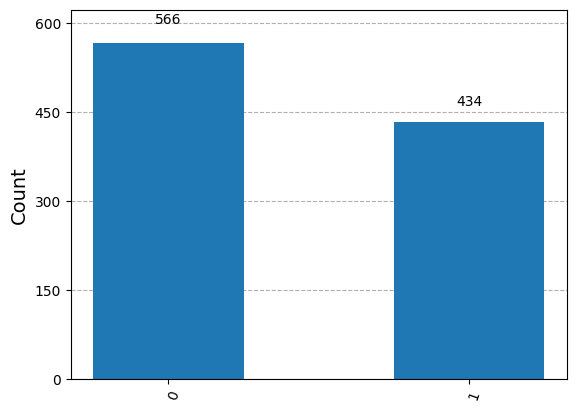

In [11]:
from qiskit.visualization import plot_histogram

statistics = v.sample_counts(1000)
display(statistics)
plot_histogram(statistics)

Trying different numbers of samples in place of $1000$ may be helpful for developing some intuition for how the number of trials influences the estimated probabilities.

#### Performing operations with `Operator` and `Statevector`

Unitary operations can be defined and performed on state vectors in Qiskit using the `Operator` class, as in the example that follows.

In [12]:
from qiskit.quantum_info import Operator

X = Operator([[0,1],[1,0]])
Y = Operator([[0,-1.j],[1.j,0]])
Z = Operator([[1,0],[0,-1]])
H = Operator([[1/sqrt(2),1/sqrt(2)],[1/sqrt(2),-1/sqrt(2)]])
S = Operator([[1,0],[0,1.j]])
T = Operator([[1,0],[0,(1+1.j)/sqrt(2)]])

v = Statevector([1,0])

v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(Z)

v.draw('latex')

<IPython.core.display.Latex object>

#### Looking ahead toward quantum circuits

Quantum circuits won't be formally introduced until Lesson 3, but we can nevertheless experiment with composing qubit unitary operations using Qiskit's `QuantumCircuit` class.
In particular, we may define a quantum circuit (which in this case will simply be a sequence of unitary operations performed on a single qubit) as follows.

In [13]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.t(0)
circuit.z(0)

circuit.draw()

┌───┐┌───┐┌───┐┌───┐┌───┐
q: ┤ H ├┤ T ├┤ H ├┤ T ├┤ Z ├
   └───┘└───┘└───┘└───┘└───┘

The operations are applied sequentially, starting on the left and ending on the right in the figure.
Let us first initialize a starting quantum state vector and then evolve that state according to the sequence of operations.

In [14]:
ket0 = Statevector([1,0])
v = ket0.evolve(circuit)
v.draw('latex')

<IPython.core.display.Latex object>

Finally, let's simulate the result of running this experiment (i.e., preparing the state $\vert 0\rangle$, applying the sequence of operations represented by the circuit, and measuring) 4000 times.

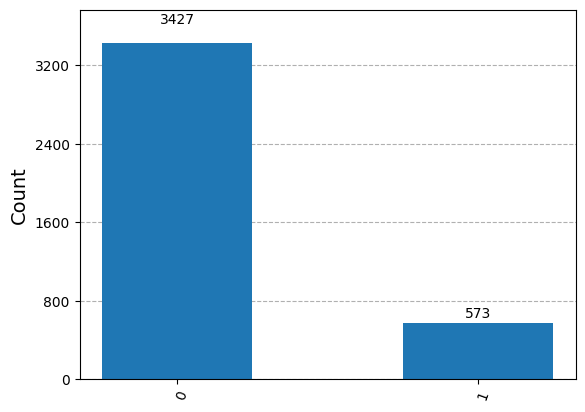

In [15]:
statistics = v.sample_counts(4000)
plot_histogram(statistics)

## End